In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import glob
import scipy.stats as stats
import astroalign as aa

In [2]:
# master dark for 60s observations
dark_data_60s = []
for filename in glob.glob("../data/ring_nebula_photometry/Dark-60s*"):
    data = fits.getdata(filename)
    dark_data_60s.append(data)
master_dark_60s = np.median(dark_data_60s, axis=0)

# Blue Data

In [3]:
dark_blue_flat_data = []
for filename in glob.glob("../data/ring_nebula_photometry/Dark-20s*"):
    data = fits.getdata(filename)
    dark_blue_flat_data.append(data)
master_dark_blue_flat = np.median(dark_blue_flat_data, axis=0)

blue_flat_data = []
for filename in glob.glob("../data/ring_nebula_photometry/Flat-B*"):
    data = fits.getdata(filename).astype(np.float64)
    data -= master_dark_blue_flat
    blue_flat_data.append(data)
median_blue_flat = np.median(blue_flat_data, axis=0)
mode_blue_flat = stats.mode(median_blue_flat.flatten())[0]
master_blue_flat = median_blue_flat / mode_blue_flat

blue_raw_data = []
for filename in glob.glob("../data/ring_nebula_photometry/Ring-B*"):
    data = fits.getdata(filename).astype(np.float64)
    data -= master_dark_60s
    blue_raw_data.append(data)
blue_combined_data = blue_raw_data / master_blue_flat

In [4]:
reference = blue_combined_data[0]

aligned_data = [reference]

for i, image in enumerate(blue_combined_data[1:], start=1):

    print(f"Aligning image {i + 1}/{len(blue_combined_data)}...")

    aligned_image, footprint = aa.register(
        image,
        reference,
        fill_value=np.nan
    )

    aligned_data.append(aligned_image)

# median combine the aligned images
stacked_image = np.nanmedian(aligned_data, axis=0)

for filename in glob.glob("../data/ring_nebula_photometry/Ring-B-60*"):
    header = fits.getheader(filename)

header["NCOMBINE"] = (
    len(aligned_data),
    "Number of images combined"
)

header["STACK"] = (
    "MEDIAN",
    "Stacking method"
)

fits.writeto(
    "../data/ring_nebula_photometry/Ring-B-stacked.fits",
    stacked_image,
    header=header,
    overwrite=True
)

print("Saved stacked image")

Aligning image 2/7...
Aligning image 3/7...
Aligning image 4/7...
Aligning image 5/7...
Aligning image 6/7...
Aligning image 7/7...
Saved stacked image


# Visible Data

In [5]:
dark_visible_flat_data = []
for filename in glob.glob("../data/ring_nebula_photometry/Dark-5s*"):
    data = fits.getdata(filename)
    dark_visible_flat_data.append(data)
master_dark_visible_flat = np.median(dark_visible_flat_data, axis=0)

visible_flat_data = []
for filename in glob.glob("../data/ring_nebula_photometry/Flat-V*"):
    data = fits.getdata(filename).astype(np.float64)
    data -= master_dark_visible_flat
    visible_flat_data.append(data)
median_visible_flat = np.median(visible_flat_data, axis=0)
mode_visible_flat = stats.mode(median_visible_flat.flatten())[0]
master_visible_flat = median_visible_flat / mode_visible_flat

visible_raw_data = []
for filename in glob.glob("../data/ring_nebula_photometry/Ring-V*"):
    data = fits.getdata(filename).astype(np.float64)
    data -= master_dark_60s
    visible_raw_data.append(data)
visible_combined_data = visible_raw_data / master_visible_flat

In [6]:
reference = visible_combined_data[0]

aligned_data = [reference]

for i, image in enumerate(visible_combined_data[1:], start=1):

    print(f"Aligning image {i + 1}/{len(visible_combined_data)}...")

    aligned_image, footprint = aa.register(
        image,
        reference,
        fill_value=np.nan
    )

    aligned_data.append(aligned_image)

# median combine the aligned images
stacked_image = np.nanmedian(aligned_data, axis=0)

for filename in glob.glob("../data/ring_nebula_photometry/Ring-V-60*"):
    header = fits.getheader(filename)

header["NCOMBINE"] = (
    len(aligned_data),
    "Number of images combined"
)

header["STACK"] = (
    "MEDIAN",
    "Stacking method"
)

fits.writeto(
    "../data/ring_nebula_photometry/Ring-V-stacked.fits",
    stacked_image,
    header=header,
    overwrite=True
)

print("Saved stacked image")

Aligning image 2/6...
Aligning image 3/6...
Aligning image 4/6...
Aligning image 5/6...
Aligning image 6/6...
Saved stacked image


# Red Data

In [3]:
dark_red_flat_data = []
for filename in glob.glob("../data/ring_nebula_photometry/Dark-2s*"):
    data = fits.getdata(filename)
    dark_red_flat_data.append(data)
master_dark_red_flat = np.median(dark_red_flat_data, axis=0)

red_flat_data = []
for filename in glob.glob("../data/ring_nebula_photometry/Flat-R*"):
    data = fits.getdata(filename).astype(np.float64)
    data -= master_dark_red_flat
    red_flat_data.append(data)
median_red_flat = np.median(red_flat_data, axis=0)
mode_red_flat = stats.mode(median_red_flat.flatten())[0]
master_red_flat = median_red_flat / mode_red_flat

red_raw_data = []
for filename in glob.glob("../data/ring_nebula_photometry/Ring-R*"):
    data = fits.getdata(filename).astype(np.float64)
    data -= master_dark_60s
    red_raw_data.append(data)
red_combined_data = red_raw_data / master_red_flat

In [4]:
reference = red_combined_data[0]

aligned_data = [reference]

for i, image in enumerate(red_combined_data[1:], start=1):

    print(f"Aligning image {i + 1}/{len(red_combined_data)}...")

    aligned_image, footprint = aa.register(
        image,
        reference,
        fill_value=np.nan
    )

    aligned_data.append(aligned_image)

# median combine the aligned images
stacked_image = np.nanmedian(aligned_data, axis=0)

for filename in glob.glob("../data/ring_nebula_photometry/Ring-R-60*"):
    header = fits.getheader(filename)

header["NCOMBINE"] = (
    len(aligned_data),
    "Number of images combined"
)

header["STACK"] = (
    "MEDIAN",
    "Stacking method"
)

fits.writeto(
    "../data/ring_nebula_photometry/Ring-R-stacked.fits",
    stacked_image,
    header=header,
    overwrite=True
)

print("Saved stacked image")

Aligning image 2/6...
Aligning image 3/6...
Aligning image 4/6...
Aligning image 5/6...
Aligning image 6/6...
Saved stacked image


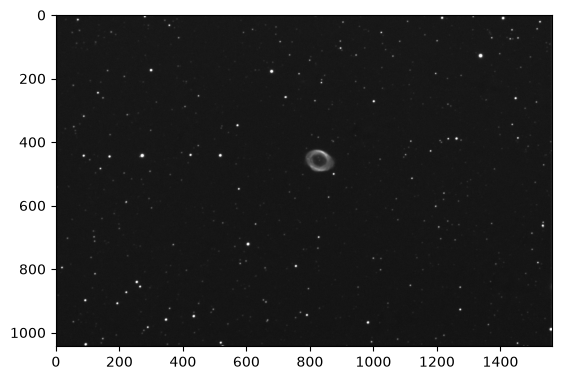

In [8]:
# display red stacked image

data_red = fits.getdata("../data/ring_nebula_photometry/Ring-R-stacked.fits")
plt.imshow(data_red, cmap="grey", vmax=800)